# Exploratory Data Analysis (EDA)

Tahap ini bertujuan untuk memahami karakteristik dataset sebelum dilakukan proses data cleaning.



In [ ]:
# Import library
!pip install langdetect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=55e0861076cfb206b9887d3a601087796f58a41db6564fa424e4be5371ea7fce
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Memuat dataset hasil penggabungan
df = pd.read_csv('/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Merge/hotel_reviews.csv')

print("Dataset berhasil dimuat.")


Dataset berhasil dimuat.


## 1. Struktur Dataset

Melihat jumlah baris, jumlah kolom, dan tipe data


In [ ]:
print("Ukuran Dataset (baris, kolom):")
print(df.shape)

print("\nInformasi Dataset:")
df.info()

Ukuran Dataset (baris, kolom):
(7821, 9)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7821 entries, 0 to 7820
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   review_text    7821 non-null   object 
 1   review_rating  7821 non-null   int64  
 2   review_date    7821 non-null   object 
 3   url            7821 non-null   object 
 4   username       7821 non-null   object 
 5   hotel_name     7821 non-null   object 
 6   city           7821 non-null   object 
 7   hotel_rating   7821 non-null   float64
 8   region         7821 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 550.0+ KB


In [ ]:
# Analisis deskriptif dataset
summary_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Unique Values': df.nunique().values,
    'Missing Values': df.isnull().sum().values,
})
# Menghitung persentase missing
summary_df['Missing (%)'] = (summary_df['Missing Values'] / len(df)) * 100
summary_df

,Column,Data Type,Non-Null Count,Unique Values,Missing Values,Missing (%)
0,review_text,object,7821,7821,0,0.0
1,review_rating,int64,7821,5,0,0.0
2,review_date,object,7821,1575,0,0.0
3,url,object,7821,7821,0,0.0
4,username,object,7821,7420,0,0.0
5,hotel_name,object,7821,87,0,0.0
6,city,object,7821,17,0,0.0
7,hotel_rating,float64,7821,22,0,0.0
8,region,object,7821,3,0,0.0


## 2. Statistik Deskriptif Rating

Menganalisis distribusi nilai rating ulasan dan rating hotel.


In [ ]:
print("Statistik Review Rating:")
print(df['review_rating'].describe())

print("\nStatistik Hotel Rating:")
print(df['hotel_rating'].describe())

Statistik Review Rating:
count    7821.000000
mean        3.818949
std         1.266509
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: review_rating, dtype: float64

Statistik Hotel Rating:
count    7821.000000
mean        4.281396
std         0.469372
min         2.800000
25%         4.100000
50%         4.300000
75%         4.600000
max         5.000000
Name: hotel_rating, dtype: float64


## 3. Distribusi Review per Region

Mengetahui sebaran jumlah ulasan pada masing-masing wilayah penelitian.


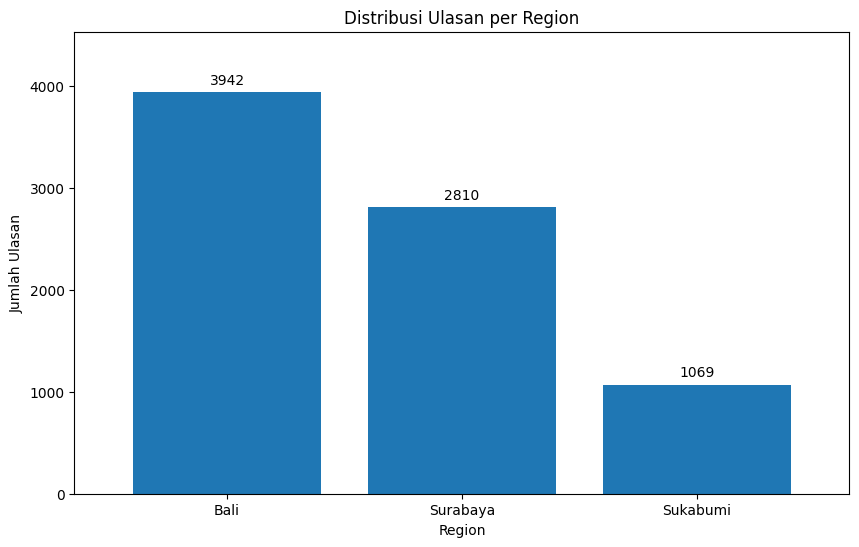

In [ ]:
import matplotlib.pyplot as plt

region_counts = df['region'].value_counts()

plt.figure(figsize=(10, 6))
ax = region_counts.plot(kind='bar', width=0.8)
plt.title("Distribusi Ulasan per Region")
plt.xlabel("Region")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=0)

for i, v in enumerate(region_counts):
    ax.text(i, v + (max(region_counts) * 0.02), str(v), ha='center')
plt.ylim(0, max(region_counts) * 1.15)
plt.show()

## 4. Distribusi Review Rating

Menganalisis kecenderungan sentimen berdasarkan rating (1–5).

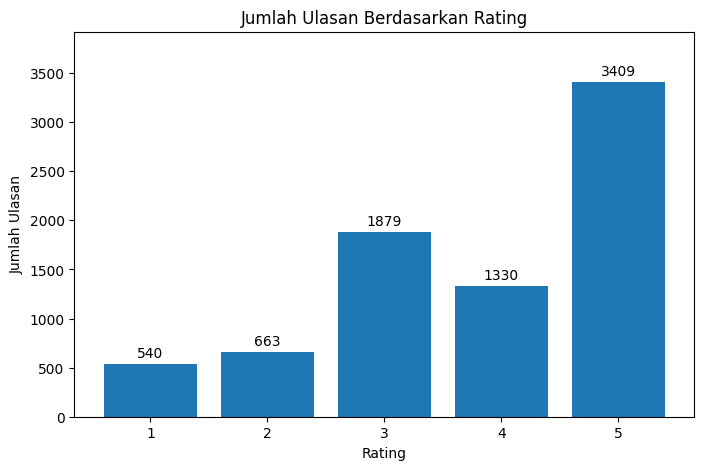

In [ ]:
import matplotlib.pyplot as plt

rating_counts = df['review_rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
ax = rating_counts.plot(kind='bar', width=0.8)
plt.title("Jumlah Ulasan Berdasarkan Rating")
plt.xlabel("Rating")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=0)

for i, v in enumerate(rating_counts):
    offset = max(rating_counts) * 0.02
    ax.text(i, v + offset, str(v), ha='center')
plt.ylim(0, max(rating_counts) * 1.15)
plt.show()

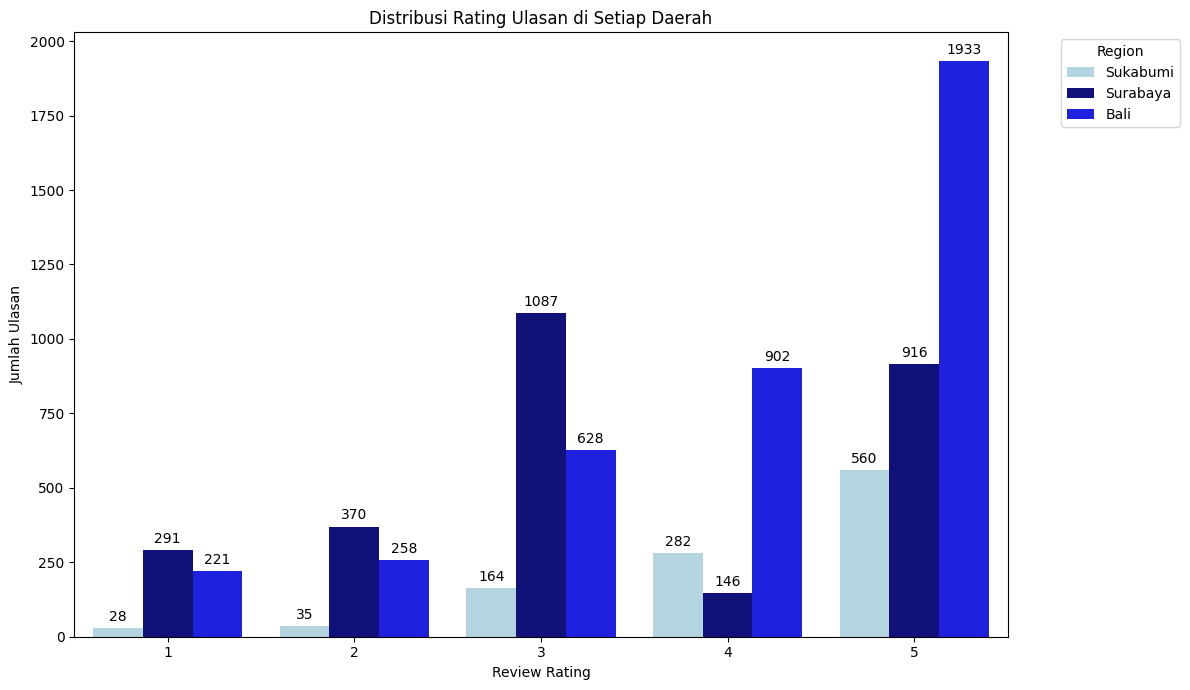

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung jumlah ulasan per rating dan per daerah
rating_region_counts = df.groupby(['region', 'review_rating']).size().unstack(fill_value=0)

# Reshape data untuk seaborn (rating di X, region sebagai hue)
rating_region_melted = rating_region_counts.reset_index().melt(id_vars='region', var_name='review_rating', value_name='Jumlah Ulasan')

# Warna untuk setiap region
region_colors = {
    'Sukabumi': 'lightblue',
    'Surabaya': 'darkblue',
    'Bali': 'blue'
}

# Definisikan urutan region
hue_order = ['Sukabumi', 'Surabaya', 'Bali']

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=rating_region_melted, x='review_rating', y='Jumlah Ulasan', hue='region', palette=region_colors, hue_order=hue_order)

plt.title('Distribusi Rating Ulasan di Setiap Daerah')
plt.xlabel('Review Rating')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=0)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

# Menambahkan label nilai pada setiap bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

## 5. Analisis Panjang Ulasan

Menghitung jumlah kata dalam setiap ulasan untuk mengetahui distribusi panjang teks.


In [ ]:
df['word_count'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))

print("Statistik Panjang Review:")
print(df['word_count'].describe())

Statistik Panjang Review:
count    7821.000000
mean       24.896049
std         8.930225
min         4.000000
25%        19.000000
50%        24.000000
75%        30.000000
max       116.000000
Name: word_count, dtype: float64


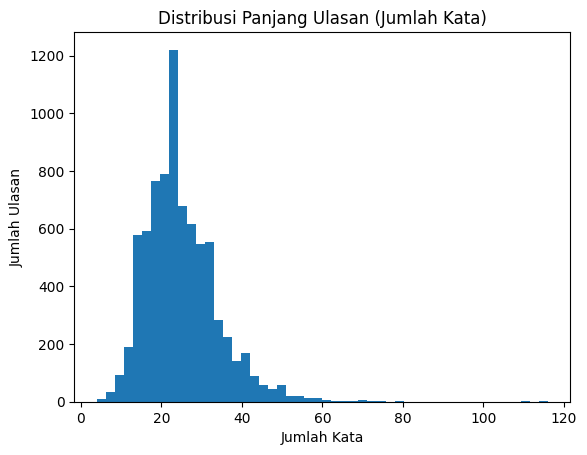

In [ ]:
plt.figure()
plt.hist(df['word_count'], bins=50)
plt.title("Distribusi Panjang Ulasan (Jumlah Kata)")
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Ulasan")
plt.show()

In [ ]:
# Filter review dengan panjang kurang dari 10 kata
long_reviews = df[df['word_count'] < 10]

print("Jumlah review dengan panjang < 10 kata:", long_reviews.shape[0])
long_reviews[['hotel_name', 'review_text' ,'region', 'word_count', 'review_date']].sort_values(by='word_count', ascending=False)

Jumlah review dengan panjang < 10 kata: 76


,hotel_name,review_text,region,word_count,review_date
5,Hotel Majapahit Surabaya - MGallery Collection,Dekorasinya sangat bagus tentang sejarah. Apal...,Surabaya,9,2025-08-09
38,Hotel Majapahit Surabaya - MGallery Collection,"Staff luar biasa, selalu menyaoa dengan baik d...",Surabaya,9,2024-11-22
2232,Morazen Surabaya,"Area lobinya bener-bener bagus, luas, dan memb...",Surabaya,9,2025-06-12 00:00:00
2164,"Four Points By Sheraton Surabaya, Tunjungan Plaza","Lokasi strategis, akses mudah dari semua lokas...",Surabaya,9,2025-07-26
1524,G Suites Hotel by AMITHYA,semua staff ramah ramah banget ❤❤❤ pelayanan y...,Surabaya,9,2024-10-21
...,...,...,...,...,...
2842,Javana Spa,Fasilitas spa yang tersedia sangat komplit.,Sukabumi,6,2025-06-10 00:00:00
4273,Swiss-Belexpress Kuta,"Good location, staff friendly and humble",Bali,6,2025-10-14
3649,Horison Hotel Sukabumi,Jaringan WiFi hotel sangat buruk,Sukabumi,5,2024-11-18 00:00:00
6341,Hard Rock Hotel Bali,Wonderful staff and fantastic service,Bali,5,2024-08-17


## 7. Distribusi Bahasa

Deteksi bahasa menggunakan library `langdetect` untuk mengidentifikasi proporsi Bahasa Indonesia dan Bahasa Inggris.


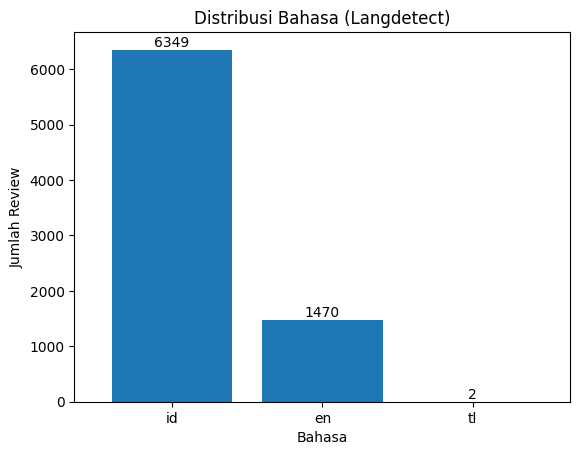

,count
language,
id,6349
en,1470
tl,2


In [ ]:
def detect_language(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return "unknown"

df['language'] = df['review_text'].apply(detect_language)
language_counts = df['language'].value_counts()

plt.figure()
ax = language_counts.plot(kind='bar', width=0.8)

plt.title("Distribusi Bahasa (Langdetect)")
plt.xlabel("Bahasa")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=0)

for i, v in enumerate(language_counts):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

language_counts

In [ ]:
# Menampilkan ulasan dengan bahasa selain Bahasa Indonesia dan Inggris
non_indo_english_reviews = df[~df['language'].isin(['id', 'en'])]
non_indo_english_reviews[['hotel_name', 'language', 'review_text']]

,hotel_name,language,review_text
208,Arcadia Surabaya Hotel,tl,shower di kamar mandi saya kurang stabil bisa ...
1591,G Suites Hotel by AMITHYA,tl,"sangat senang karena kamarnya sangat bersih, s..."


In [ ]:
# Manual Corection untuk ulasan selain bahasa Indonesia dan Inggris
# Cek jumlah sebelum koreksi
print("Sebelum koreksi:")
print(df['language'].value_counts())

# Manual correction
df.loc[df['language'].isin(['tl', 'et', 'de']), 'language'] = 'id'

# Cek setelah koreksi
print("\nSetelah koreksi:")
print(df['language'].value_counts())

Sebelum koreksi:
language
id    6349
en    1470
tl       2
Name: count, dtype: int64

Setelah koreksi:
language
id    6351
en    1470
Name: count, dtype: int64


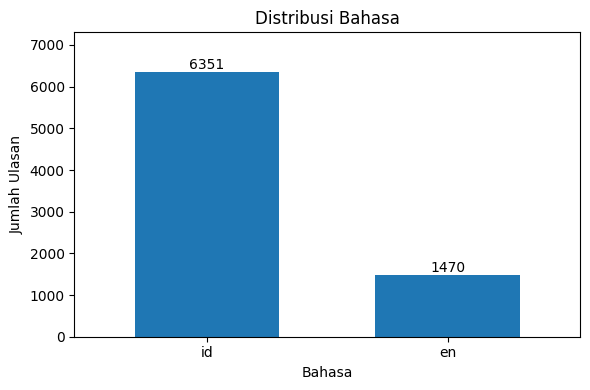

,count
language,
id,6351
en,1470


In [ ]:
language_counts = df['language'].value_counts()

plt.figure(figsize=(6,4))
ax = language_counts.plot(kind='bar', width=0.6)
plt.title("Distribusi Bahasa")
plt.xlabel("Bahasa")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=0)
max_height = language_counts.max()
plt.ylim(0, max_height * 1.15)

for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()
language_counts

## Distribusi Ulasan dan Hotel


In [ ]:
import pandas as pd
from IPython.display import display

pd.set_option('display.max_rows', None)

# ===============================
# Jumlah ulasan per hotel
# ===============================
hotel_review_counts = (
    df.groupby(['hotel_name', 'region'])
      .agg(
          jumlah_ulasan=('review_text', 'count'),
          hotel_rating=('hotel_rating', 'first'),
          hotel_city=('city', 'first')
      )
      .reset_index()
      .sort_values(
          by=['region', 'hotel_rating', 'jumlah_ulasan'],
          ascending=[True, False, False]
      )
)

hotel_review_counts = hotel_review_counts[
    ['jumlah_ulasan', 'hotel_name', 'region', 'hotel_rating', 'hotel_city']
]

print("=== DATA HOTEL DAN JUMLAH ULASAN ===")
display(hotel_review_counts)


# ===============================
# Jumlah hotel per wilayah
# ===============================
jumlah_hotel_per_wilayah = (
    hotel_review_counts.groupby('region')['hotel_name']
    .nunique()
    .reset_index(name='jumlah_hotel')
)

print("=== JUMLAH HOTEL PER WILAYAH ===")
display(jumlah_hotel_per_wilayah)


# ===============================
# Total ulasan per wilayah
# ===============================
total_ulasan_per_wilayah = (
    hotel_review_counts.groupby('region')['jumlah_ulasan']
    .sum()
    .reset_index(name='total_ulasan')
)

print("=== TOTAL ULASAN PER WILAYAH ===")
display(total_ulasan_per_wilayah)

=== DATA HOTEL DAN JUMLAH ULASAN ===


,jumlah_ulasan,hotel_name,region,hotel_rating,hotel_city
85,265,Wapa di Ume Sidemen,Bali,5.0,Sidemen
17,4,Embang Homestay,Bali,5.0,Sidemen
77,362,Swiss-Belexpress Kuta,Bali,4.8,Kuta
66,2,Puri Clinton Home Stay,Bali,4.8,Nusa Dua
21,140,Four Seasons Resort Bali at Jimbaran Bay,Bali,4.7,Jimbaran
84,97,The Royal Pita Maha,Bali,4.7,Kedewatan
76,6,Suryadina Guest House,Bali,4.7,Ubud
0,422,ARTOTEL Sanur,Bali,4.6,Sanur
54,110,M Boutique Hostel,Bali,4.6,Kerobokan
29,22,Gusti Kaler House,Bali,4.6,Ubud


=== JUMLAH HOTEL PER WILAYAH ===


,region,jumlah_hotel
0,Bali,35
1,Sukabumi,17
2,Surabaya,35


=== TOTAL ULASAN PER WILAYAH ===


,region,total_ulasan
0,Bali,3942
1,Sukabumi,1069
2,Surabaya,2810


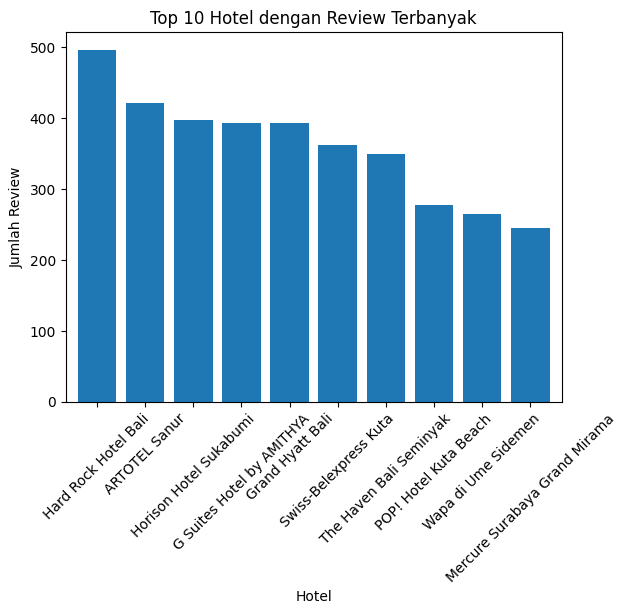

,count
hotel_name,
Hard Rock Hotel Bali,497
ARTOTEL Sanur,422
Horison Hotel Sukabumi,397
G Suites Hotel by AMITHYA,394
Grand Hyatt Bali,393
Swiss-Belexpress Kuta,362
The Haven Bali Seminyak,350
POP! Hotel Kuta Beach,277
Wapa di Ume Sidemen,265


In [ ]:
top_hotels = df['hotel_name'].value_counts().head(10)

plt.figure()
top_hotels.plot(kind='bar', width=0.8)
plt.title("Top 10 Hotel dengan Review Terbanyak")
plt.xlabel("Hotel")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=45)
plt.show()

top_hotels

## Wordcloud Ulasan

Visualisasi wordcloud untuk melihat kata-kata yang paling sering muncul dalam ulasan hotel.


Total karakter: 1269010


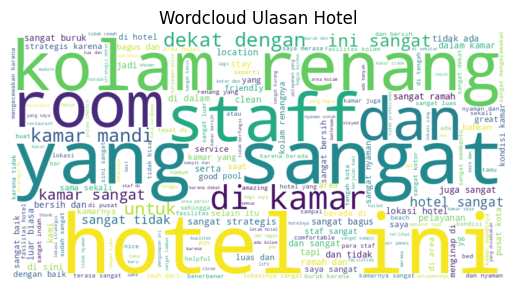

In [ ]:
!pip install wordcloud
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Menggabungkan seluruh review menjadi satu string besar
all_text = " ".join(df['review_text'].astype(str))
print("Total karakter:", len(all_text))

# Membersihkan teks
clean_text = re.sub(r'[^a-zA-Z\s]', '', all_text)
clean_text = clean_text.lower()

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200
).generate(clean_text)

plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud Ulasan Hotel")
plt.show()


Total karakter: 1327213


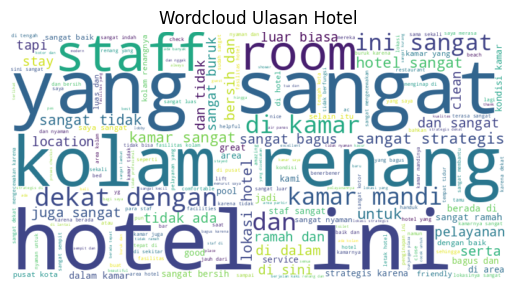

In [ ]:
!pip install wordcloud
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Menggabungkan seluruh review menjadi satu string besar
all_text = " ".join(df['review_text'].astype(str))
print("Total karakter:", len(all_text))

# Membersihkan teks
clean_text = re.sub(r'[^a-zA-Z\s]', '', all_text)
clean_text = clean_text.lower()

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200
).generate(clean_text)

plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud Ulasan Hotel")
plt.show()


In [ ]:
df.head()

,review_text,review_rating,review_date,url,username,hotel_name,city,hotel_rating,region,word_count,language
0,Pertama kali disini super kagum sama interior ...,5,2025-09-13,https://www.tripadvisor.com/ShowUserReviews-g2...,Deby A,Hotel Majapahit Surabaya - MGallery Collection,Surabaya,4.7,Surabaya,18,id
1,Pelayanan oke banget dibantu dengan resepsioni...,5,2025-09-13,https://www.tripadvisor.com/ShowUserReviews-g2...,Mobile26477862893,Hotel Majapahit Surabaya - MGallery Collection,Surabaya,4.7,Surabaya,12,id
2,Kolam renang dan gym nya sangat bagus dan yang...,5,2025-08-27,https://www.tripadvisor.com/ShowUserReviews-g2...,Farid P,Hotel Majapahit Surabaya - MGallery Collection,Surabaya,4.7,Surabaya,13,id
3,Kami Sekeluarga senang. Kamarnya bersih dan ny...,5,2025-08-27,https://www.tripadvisor.com/ShowUserReviews-g2...,Navigate56583167160,Hotel Majapahit Surabaya - MGallery Collection,Surabaya,4.7,Surabaya,18,id
4,Perbotan kamar seperti AC dan dispenser air mi...,1,2025-08-26,https://www.tripadvisor.com/ShowUserReviews-g2...,robin,Hotel Majapahit Surabaya - MGallery Collection,Surabaya,4.7,Surabaya,15,id


In [ ]:
# Drop kolom yang tidak diperlukan
# df = df.drop(columns=['word_count'])

print("Ukuran final dataset:", df.shape)
df.head()

# Save
output_path = "/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_EDA/hotel_reviews.xlsx"
df.to_excel(output_path, index=False)

output_path = "/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_EDA/hotel_reviews.csv"
df.to_csv(output_path, index=False, encoding='utf-8')
print("Dataset berhasil disimpan!")

Ukuran final dataset: (7821, 11)
Dataset berhasil disimpan!
